# Clustering
You should build an end-to-end machine learning pipeline using a clustering model. In particular, you should do the following:
- Load the `customers` dataset using [Pandas](https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html). You can find this dataset in the datasets folder.
- Conduct data exploration, data preprocessing, and feature engineering if necessary.
- Choose a few clustering algorithms, such as [k-means](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html), [hdbscan](https://hdbscan.readthedocs.io/en/latest/), and [agglomerative clustering](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.AgglomerativeClustering.html).
- Train and evaluate clustering models (i.e., the clustering algorithm and its hyperparameters) to find out the best-performing model using clustering evaluation metrics, such as [elbow method](https://www.scikit-yb.org/en/latest/api/cluster/elbow.html) and the [silhouette score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html).
- Check the documentation to identify the most important hyperparameters, attributes, and methods of the model. Use them in practice.

# **Importing some libraries**

In [1]:
import pandas as pd
import os

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from yellowbrick.cluster import KElbowVisualizer
import hdbscan
import matplotlib.pyplot as plt
from sklearn.model_selection import ParameterGrid

import warnings

In [2]:
os.system('color')

RED = '\033[31m'
BLUE = '\033[34m'
RESET = '\033[0m'

In [3]:
df = pd.read_csv("https://raw.githubusercontent.com/m-mahdavi/teaching/refs/heads/main/datasets/customers.csv")
print(BLUE + "df.head()")
display(df.head())
print("")

print(BLUE + "df.info()" + RESET)
display(df.info())
print("")

print(BLUE + "df.isnull().sum()")
display(df.isnull().sum())
print("")

print(BLUE + "df.describe()")
display(df.describe())

df.head()


,ID,Sex,Marital status,Age,Education,Income,Occupation,Settlement size
0,100000001,0,0,67,2,124670,1,2
1,100000002,1,1,22,1,150773,1,2
2,100000003,0,0,49,1,89210,0,0
3,100000004,0,0,45,1,171565,1,1
4,100000005,0,0,53,1,149031,1,1



df.info()
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   ID               2000 non-null   int64
 1   Sex              2000 non-null   int64
 2   Marital status   2000 non-null   int64
 3   Age              2000 non-null   int64
 4   Education        2000 non-null   int64
 5   Income           2000 non-null   int64
 6   Occupation       2000 non-null   int64
 7   Settlement size  2000 non-null   int64
dtypes: int64(8)
memory usage: 125.1 KB


None


df.isnull().sum()


,0
ID,0
Sex,0
Marital status,0
Age,0
Education,0
Income,0
Occupation,0
Settlement size,0



df.describe()


,ID,Sex,Marital status,Age,Education,Income,Occupation,Settlement size
count,2.000000e+03,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,1.000010e+08,0.457000,0.496500,35.909000,1.03800,120954.419000,0.810500,0.739000
std,5.774946e+02,0.498272,0.500113,11.719402,0.59978,38108.824679,0.638587,0.812533
min,1.000000e+08,0.000000,0.000000,18.000000,0.00000,35832.000000,0.000000,0.000000
25%,1.000005e+08,0.000000,0.000000,27.000000,1.00000,97663.250000,0.000000,0.000000
50%,1.000010e+08,0.000000,0.000000,33.000000,1.00000,115548.500000,1.000000,1.000000
75%,1.000015e+08,1.000000,1.000000,42.000000,1.00000,138072.250000,1.000000,1.000000
max,1.000020e+08,1.000000,1.000000,76.000000,3.00000,309364.000000,2.000000,2.000000


In [4]:
print(RED + "df.columns before removing 'ID' Column:" + BLUE)
print(df.columns , RESET, df.shape)
df = df.drop(columns=['ID'], errors='ignore')
print("")
print(RED + "df.columns after removing 'ID' Column:" + BLUE)
print(df.columns, RESET , df.shape)

df.columns before removing 'ID' Column:
Index(['ID', 'Sex', 'Marital status', 'Age', 'Education', 'Income',
       'Occupation', 'Settlement size'],
      dtype='object')  (2000, 8)

df.columns after removing 'ID' Column:
Index(['Sex', 'Marital status', 'Age', 'Education', 'Income', 'Occupation',
       'Settlement size'],
      dtype='object')  (2000, 7)


In [53]:
kmeans_param_grid = {
    'n_clusters': range(2, 11),
    'init': ['k-means++', 'random'],
    'n_init': range(1, 21, 5),
    'max_iter': range(10, 201, 10),
    'random_state': [30]
}

hdbscan_param_grid = {
    'min_cluster_size': range(2, 11),
    'min_samples': range(1,5),
    'metric': ['euclidean', 'manhattan'],
    'cluster_selection_method': ['eom']
}


In [54]:
def evaluate_model(model, df, model_name):
    labels = model.fit_predict(df)
    score = silhouette_score(df, labels)
    #print(f"{RED}{model_name} Silhouette Score: {BLUE}{score}")
    return score

warnings.filterwarnings("ignore", category=FutureWarning)

best_model = None
best_score = -1
best_params = None
best_model_name = None

for params in ParameterGrid(kmeans_param_grid):
    kmeans = KMeans(**params)
    score = evaluate_model(kmeans, df, "KMeans")
    if score > best_score:
      best_score = score
      best_params = params
      best_model = kmeans
      best_model_name = "KMeans"


for params in ParameterGrid(hdbscan_param_grid):
    hdbscan_cluster = hdbscan.HDBSCAN(**params)
    score = evaluate_model(hdbscan_cluster, df, "HDBSCAN")
    if score > best_score:
      best_score = score
      best_params = params
      best_model = hdbscan_cluster
      best_model_name = "HDBSCAN"



print(f"{RED}\nBest Model: {BLUE}{best_model_name}")
print(f"{RED}Best Parameters: {BLUE}{best_params}")
print(f"{RED}Best Silhouette Score: {BLUE}{best_score}")



Best Model: KMeans
Best Parameters: {'init': 'k-means++', 'max_iter': 10, 'n_clusters': 2, 'n_init': 1, 'random_state': 30}
Best Silhouette Score: 0.5841566348628164


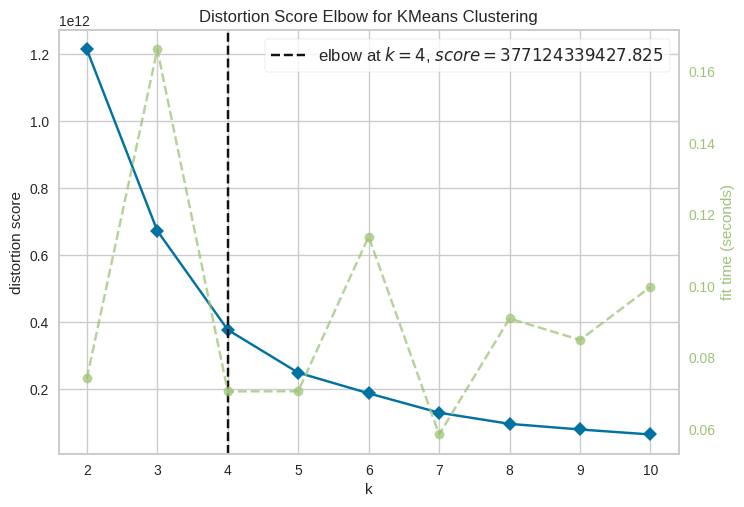

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [37]:
visualizer = KElbowVisualizer(kmeans)
visualizer.fit(df)
visualizer.show()